In [43]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [44]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'
TEST_YEAR = '2018'

In [45]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(38856, 91)


In [46]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [47]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL61,EL611,καλαμπακας,2018,1,21.15549,39.67943,0.217977,0.590945,-0.248245,-0.590945,0.311025,0.633913,-0.269263,-0.633913,0.132428,0.063925,0.092908,0.063925,-1.551290,-0.742903,-0.877143,1.356452,13.425333,-1.210000,-0.771538,-1.170000,1.891905,4.371333,-1.380645,-0.757221,-1.023571,1.624178,8.898333,-9.27,7.45,13.031919,49.610618,176.695387,248.380797,141.025684,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.000000,16.333333,21.000000,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.0,2.204379,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
1,1,EL61,EL611,καλαμπακας,2018,1,21.17860,39.62553,-0.029931,0.597879,0.087187,-0.597879,-0.026764,0.602885,0.088955,-0.602885,0.026222,0.135749,0.058761,0.135749,-1.596452,-1.434516,-0.573571,1.802258,14.608000,0.208065,0.636667,0.290000,2.454800,4.674000,-0.694194,-0.398925,-0.141786,2.128529,9.641000,-7.45,1.59,13.031919,49.610618,176.695387,248.380797,141.025684,8.875000,18.416667,44.918699,890.639454,33.0,-8.0,41.0,-1.000000,15.333333,19.666667,-2.833333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.0,3.146997,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
2,2,EL61,EL611,καλαμπακας,2018,1,21.17860,39.64350,0.350718,0.334789,-0.346537,-0.334789,0.219293,0.451410,-0.138668,-0.451410,0.161567,0.114799,0.197202,0.114799,1.869355,1.552581,1.537143,3.870645,15.974667,0.401613,0.943548,-0.373571,1.705484,5.735333,1.135484,1.248065,0.581786,2.788065,10.855000,-5.99,7.87,13.031919,49.610618,176.695387,248.380797,141.025684,11.250000,20.166667,50.416667,761.726508,34.0,-6.0,40.0,2.666667,16.833333,20.833333,1.833333,1906.0,495.0,14.0,93.819631,1164.0,136.0,151.0,797.0,15,10,10,5,5,7,1,1,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.0,6.601146,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
3,3,EL61,EL611,καλαμπακας,2018,1,21.17860,39.66147,0.018524,0.719844,-0.034510,-0.719844,0.002419,0.649489,0.031371,-0.649489,0.059191,0.085617,0.115935,0.085617,-2.469355,-1.130000,-0.020714,2.381613,13.402000,-0.791290,-11.302667,-0.530000,1.957333,6.033478,-1.630323,-6.216333,-0.275357,2.169473,9.717739,-9.87,1.79,13.031919,49.610618,176.695387,248.380797,141.025684,9.083333,17.666667,42.063492,912.995403,33.0,-9.0,42.0,-1.666667,15.500000,20.000000,-2.833333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,21965.416299,1733.325556,34,191.955968,1620.724029,160.444289,0.0,1.083714,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
4,4,EL61,EL611,καλαμπακας,2018,1,21.17860,39.67943,0.350009,0.185395,-0.308441,-0.185395,0.234668,0.325853,-0.166595,-0.325853,0.141985,0.187865,0.206284,0.187865,1.402258,2.057742,3.939286,7.365484,18.2286

In [48]:
len(data_train.cell_code.unique())

4260

In [49]:
len(data_test.cell_number.unique())

3238

In [50]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [51]:
data_train.cases.sum()

1364

In [52]:
# data_test.cases.sum()

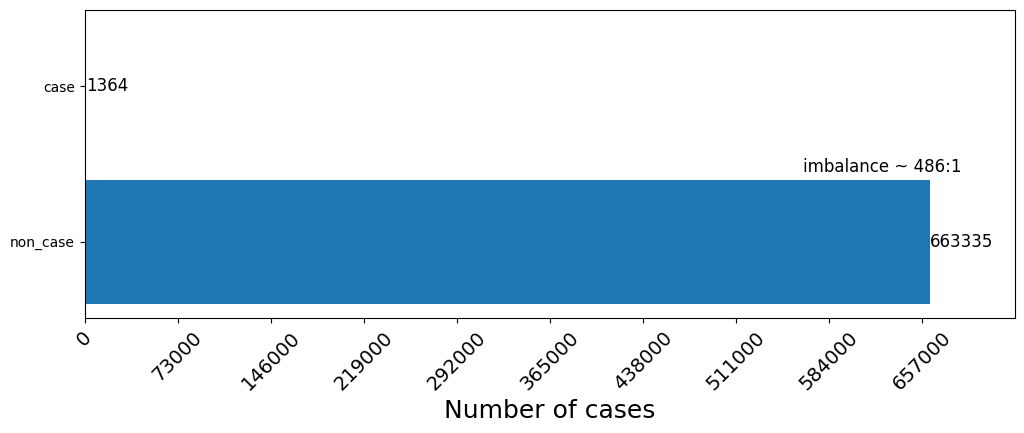

In [53]:
plot_imbalance(data_train, target_column='cases')

In [54]:
# plot_imbalance(data_test, target_column='cases')

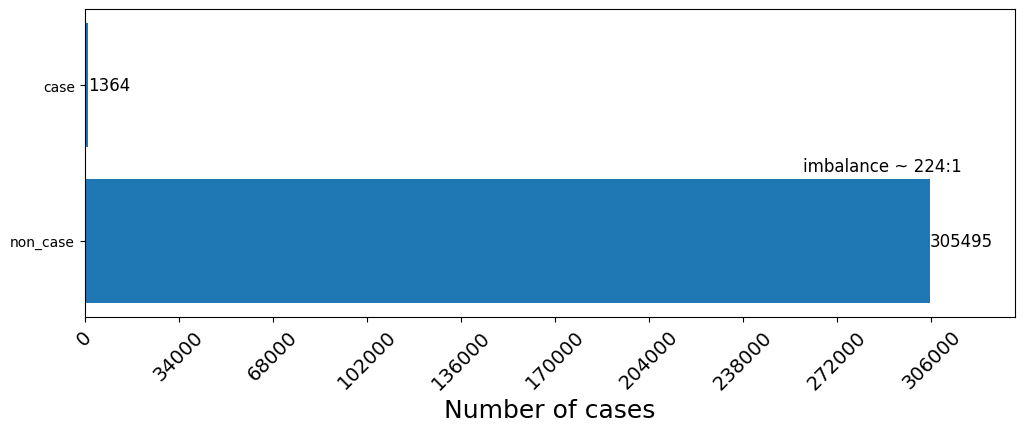

In [55]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [56]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [57]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

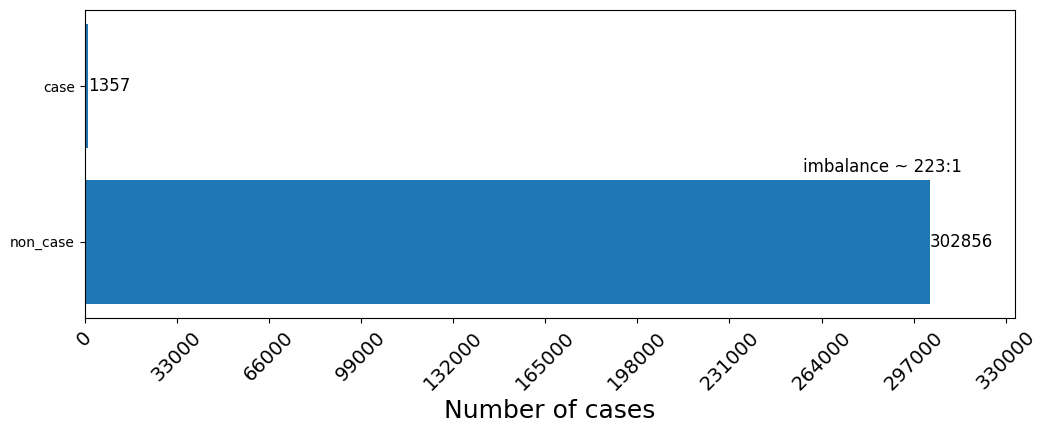

In [58]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

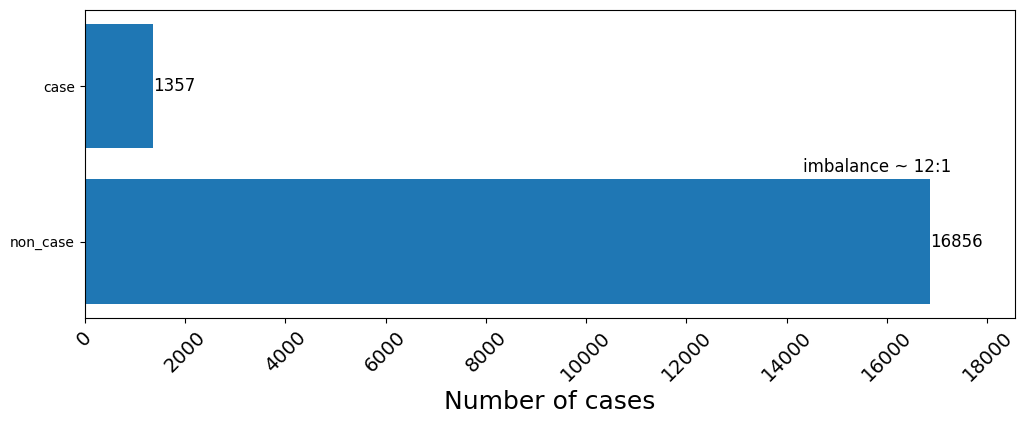

In [59]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [60]:
data_train.shape

(18074, 94)

In [61]:
data_train.cases.sum()

1357

In [62]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1419,262,1681,5.42%
1,2011,1394,100,1494,13.94%
2,2012,1396,157,1553,8.89%
3,2013,1446,85,1531,17.01%
4,2014,1359,15,1374,90.60%
5,2015,1443,0,1443,inf%
6,2016,1445,0,1445,inf%
7,2017,1367,42,1409,32.55%
8,2018,1234,289,1523,4.27%
9,2019,1450,218,1668,6.65%


In [63]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [64]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 12.42
Weight: 12.42


In [65]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [66]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL61,EL611,καλαμπακας,2018,5,21.15549,39.67943,0.288243,0.315041,-0.310199,-0.315041,0.301347,0.424341,-0.299457,-0.424341,0.165512,0.156302,0.120162,0.156302,13.425333,-0.742903,-0.877143,1.356452,13.425333,4.371333,-0.771538,-1.170000,1.891905,4.371333,8.898333,-0.757221,-1.023571,1.624178,8.898333,1.39,21.79,1.327792,13.274726,14.268760,39.833758,1156.471607,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.000000,16.333333,21.000000,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3,0.500000,-0.866025
1,1,EL61,EL611,καλαμπακας,2018,5,21.17860,39.62553,0.057674,0.440634,-0.100818,-0.440634,0.035742,0.561458,-0.080691,-0.561458,0.066623,0.188130,0.059395,0.188130,14.608000,-1.434516,-0.573571,1.802258,14.608000,4.674000,0.636667,0.290000,2.454800,4.674000,9.641000,-0.398925,-0.141786,2.128529,9.641000,-1.45,24.17,1.327792,13.274726,14.268760,39.833758,1156.471607,8.875000,18.416667,44.918699,890.639454,33.0,-8.0,41.0,-1.000000,15.333333,19.666667,-2.833333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3,0.500000,-0.866025
2,2,EL61,EL611,καλαμπακας,2018,5,21.17860,39.64350,0.403996,0.077949,-0.386689,-0.077949,0.372004,0.236865,-0.344195,-0.236865,0.172480,0.156974,0.114621,0.156974,15.974667,1.552581,1.537143,3.870645,15.974667,5.735333,0.943548,-0.373571,1.705484,5.735333,10.855000,1.248065,0.581786,2.788065,10.855000,-1.15,25.55,1.327792,13.274726,14.268760,39.833758,1156.471607,11.250000,20.166667,50.416667,761.726508,34.0,-6.0,40.0,2.666667,16.833333,20.833333,1.833333,1906.0,495.0,14.0,93.819631,1164.0,136.0,151.0,797.0,15,10,10,5,5,7,1,1,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3,0.500000,-0.866025
3,3,EL61,EL611,καλαμπακας,2018,5,21.17860,39.66147,0.017036,0.544332,-0.085958,-0.544332,0.065160,0.374690,-0.095170,-0.374690,0.056057,0.103587,0.045251,0.103587,13.402000,-1.130000,-0.020714,2.381613,13.402000,6.033478,-11.302667,-0.530000,1.957333,6.033478,11.205217,-6.216333,-0.275357,2.169473,9.717739,3.29,22.31,1.327792,13.274726,14.268760,39.833758,1156.471607,9.083333,17.666667,42.063492,912.995403,33.0,-9.0,42.0,-1.666667,15.500000,20.000000,-2.833333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,21965.416299,1733.325556,34,191.955968,1620.724029,160.444289,0.000000,1.083714,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3,0.500000,-0.866025
4,4,EL61,EL611,καλαμπακας,2018,5,21.17860,39.67943,0.515666,0.072706,-0.474067,-0.072706,0.406592

### Results 2018 ###

In [67]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [68]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [69]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [70]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [71]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [72]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [73]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1697,1697,EL61,EL612,λαρισαιων,2018,5,22.21850,39.58960,0.161354
1744,1744,EL61,EL612,λαρισαιων,2018,5,22.24161,39.60757,0.150890
1049,1049,EL61,EL611,φαρκαδονας,2018,5,21.94119,39.53570,0.146095
1872,1872,EL61,EL612,φαρσαλων,2018,5,22.31094,39.32010,0.128355
814,814,EL61,EL611,τρικκαιων,2018,5,21.80254,39.55367,0.127127


In [74]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2081,2081,EL61,EL612,λαρισαιων,2018,6,22.40337,39.66147,0.609212
1790,1790,EL61,EL612,λαρισαιων,2018,6,22.26472,39.60757,0.571235
1898,1898,EL61,EL612,τυρναβου,2018,6,22.31094,39.78723,0.535858
1734,1734,EL61,EL612,κιλελερ,2018,6,22.24161,39.42790,0.501345
2085,2085,EL61,EL612,λαρισαιων,2018,6,22.40337,39.73333,0.492859


In [75]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2081,2081,EL61,EL612,λαρισαιων,2018,7,22.40337,39.66147,0.927628
2125,2125,EL61,EL612,λαρισαιων,2018,7,22.42648,39.62553,0.925911
1997,1997,EL61,EL612,τυρναβου,2018,7,22.35715,39.75130,0.917665
2126,2126,EL61,EL612,λαρισαιων,2018,7,22.42648,39.64350,0.916725
2041,2041,EL61,EL612,τυρναβου,2018,7,22.38026,39.73333,0.909101


In [76]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2084,2084,EL61,EL612,λαρισαιων,2018,8,22.40337,39.71537,0.980134
1997,1997,EL61,EL612,τυρναβου,2018,8,22.35715,39.75130,0.969968
1330,1330,EL61,EL612,ελασσονας,2018,8,22.05674,39.80520,0.962924
1331,1331,EL61,EL612,ελασσονας,2018,8,22.05674,39.82317,0.960583
2126,2126,EL61,EL612,λαρισαιων,2018,8,22.42648,39.64350,0.958693


In [77]:
results_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2084,2084,EL61,EL612,λαρισαιων,2018,9,22.40337,39.71537,0.969044
2081,2081,EL61,EL612,λαρισαιων,2018,9,22.40337,39.66147,0.945832
2173,2173,EL61,EL612,λαρισαιων,2018,9,22.44959,39.66147,0.939893
1997,1997,EL61,EL612,τυρναβου,2018,9,22.35715,39.75130,0.933649
2080,2080,EL61,EL612,λαρισαιων,2018,9,22.40337,39.64350,0.932713


In [78]:
results_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2084,2084,EL61,EL612,λαρισαιων,2018,10,22.40337,39.71537,0.616201
3005,3005,EL61,EL613,ρηγα φερραιου,2018,10,22.86555,39.49977,0.574024
2968,2968,EL61,EL613,ρηγα φερραιου,2018,10,22.84244,39.46383,0.481449
1385,1385,EL61,EL612,ελασσονας,2018,10,22.07985,39.82317,0.472138
2178,2178,EL61,EL612,τεμπων,2018,10,22.44959,39.75130,0.464042


In [79]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [80]:
region_grid.head()

,cell_numbe,NUTS2_ID,x,y,geometry
0,0,EL61,21.15549,39.67943,"POLYGON ((21.16704 39.67045, 21.14393 39.67045..."
1,1,EL61,21.17860,39.62553,"POLYGON ((21.19015 39.61655, 21.16704 39.61655..."
2,2,EL61,21.17860,39.64350,"POLYGON ((21.19015 39.63452, 21.16704 39.63452..."
3,3,EL61,21.17860,39.66147,"POLYGON ((21.19015 39.65248, 21.16704 39.65248..."
4,4,EL61,21.17860,39.67943,"POLYGON ((21.19015 39.67045, 21.16704 39.67045..."


In [81]:
greece_nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [82]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [83]:
greece_lakes.head()

,objectid,EU_CD,MS_CD,NAME,ALTNAME1,ALTNAME2,ALTNAME3,BASIN_CD,CHARACTER_,shape_area,shape_len,geometry
0,1,GR001100030020H,001100030020H,????? ???????,KERKINI LAKE,None,None,11,Insufficient Data,46088780.0,70604.0100,"POLYGON ((23.08306 41.19977, 23.08406 41.20032..."
1,2,GR001200030030N,001200030030N,????? ????????,ISMARIDA LAKE,None,None,12,Insufficient Data,1865103.9,5520.0850,"POLYGON ((25.30798 40.99044, 25.30862 40.99215..."
2,3,GR000800030010H,000800030010H,??????? ????? ??????,KARLAS RESERVOIR,None,None,08,Insufficient Data,34925588.0,29704.8950,"POLYGON ((22.78068 39.49602, 22.78083 39.49649..."
3,4,GR000800030020H,000800030020H,??????? ????? ????????,SMOKOVO RESERVOIR,None,None,08,Insufficient Data,9917521.0,57610.2000,"POLYGON ((22.04919 39.10001, 22.05059 39.10001..."
4,5,GR001300030020N,001300030020N,????? ??????,KOURNA LAKE,None,None,13,No Risk,561666.4,2849.8203,"POLYGON ((24.27341 35.33136, 24.27384 35.33312..."


In [84]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [85]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.16704 39.67045, 21.14393 39.67045..."
1,1,"POLYGON ((21.19015 39.61655, 21.16704 39.61655..."
2,2,"POLYGON ((21.19015 39.63452, 21.16704 39.63452..."
3,3,"POLYGON ((21.19015 39.65248, 21.16704 39.65248..."
4,4,"POLYGON ((21.19015 39.67045, 21.16704 39.67045..."


In [86]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL61,Θεσσαλία,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [87]:
greece_lau1.head()

,NAME,geometry
0,Αγιάς,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αλοννήσου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
2,Αλμυρού,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
3,Αργιθέας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
4,Βόλου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [88]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,SMOKOVO RESERVOIR,9917521.0,57610.200,"POLYGON ((22.15620 39.12133, 22.15606 39.12153...",0
1,KARLAS RESERVOIR,34925588.0,29704.895,"POLYGON ((22.78083 39.49649, 22.78114 39.49670...",1
2,TAVROPOS RESERVOIR,23560746.0,85317.960,"POLYGON ((21.69880 39.34183, 21.69943 39.34191...",2


In [89]:
results_may = pd.merge(results_may, region_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')
results_may['x'] = results_may['x'].round(4)
results_may['y'] = results_may['y'].round(4)
results_may.rename(columns={'score': 'risk_score'}, inplace=True)
results_may['risk_score'] = results_may['risk_score'].round(6)

results_jun = pd.merge(results_jun, region_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')
results_jun['x'] = results_jun['x'].round(4)
results_jun['y'] = results_jun['y'].round(4)
results_jun.rename(columns={'score': 'risk_score'}, inplace=True)
results_jun['risk_score'] = results_jun['risk_score'].round(6)

results_jul = pd.merge(results_jul, region_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')
results_jul['x'] = results_jul['x'].round(4)
results_jul['y'] = results_jul['y'].round(4)
results_jul.rename(columns={'score': 'risk_score'}, inplace=True)
results_jul['risk_score'] = results_jul['risk_score'].round(6)

results_aug = pd.merge(results_aug, region_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')
results_aug['x'] = results_aug['x'].round(4)
results_aug['y'] = results_aug['y'].round(4)
results_aug.rename(columns={'score': 'risk_score'}, inplace=True)
results_aug['risk_score'] = results_aug['risk_score'].round(6)

results_sep = pd.merge(results_sep, region_grid, on='cell_number', how='left')
results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')
results_sep['x'] = results_sep['x'].round(4)
results_sep['y'] = results_sep['y'].round(4)
results_sep.rename(columns={'score': 'risk_score'}, inplace=True)
results_sep['risk_score'] = results_sep['risk_score'].round(6)

results_oct = pd.merge(results_oct, region_grid, on='cell_number', how='left')
results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')
results_oct['x'] = results_oct['x'].round(4)
results_oct['y'] = results_oct['y'].round(4)
results_oct.rename(columns={'score': 'risk_score'}, inplace=True)
results_oct['risk_score'] = results_oct['risk_score'].round(6)

In [90]:
# results_may.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_aug.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_sep.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [91]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15, 6)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

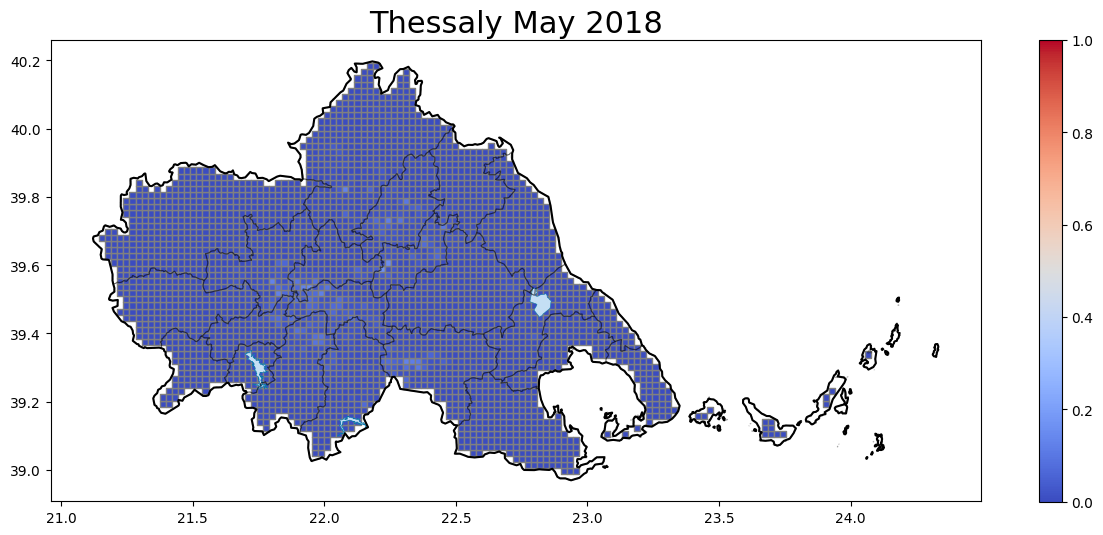

In [92]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)

plt.title(f'{NUTS2} {month_dict.get(results_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

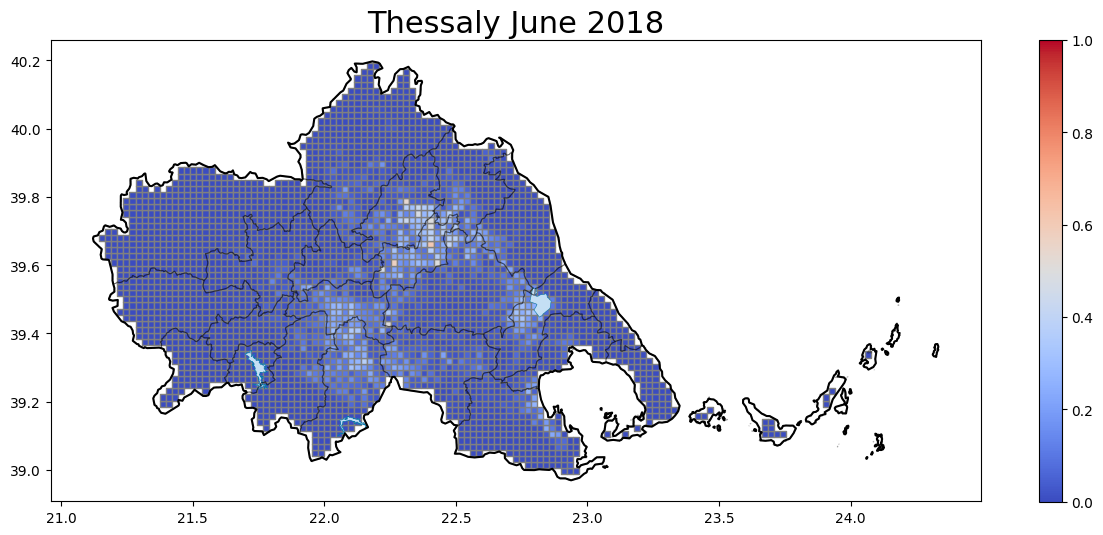

In [93]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)

plt.title(f'{NUTS2} {month_dict.get(results_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

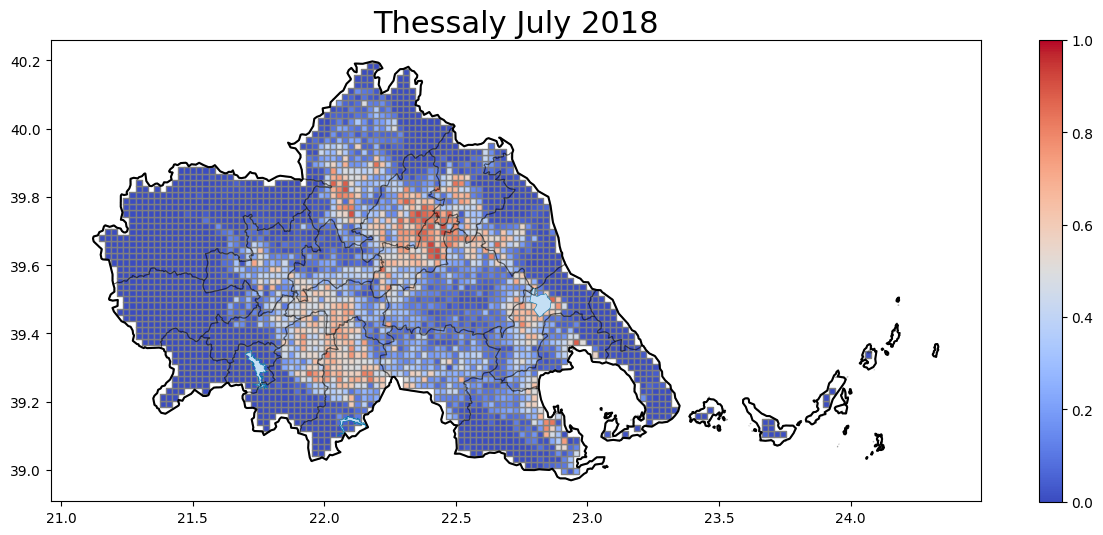

In [94]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)

plt.title(f'{NUTS2} {month_dict.get(results_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

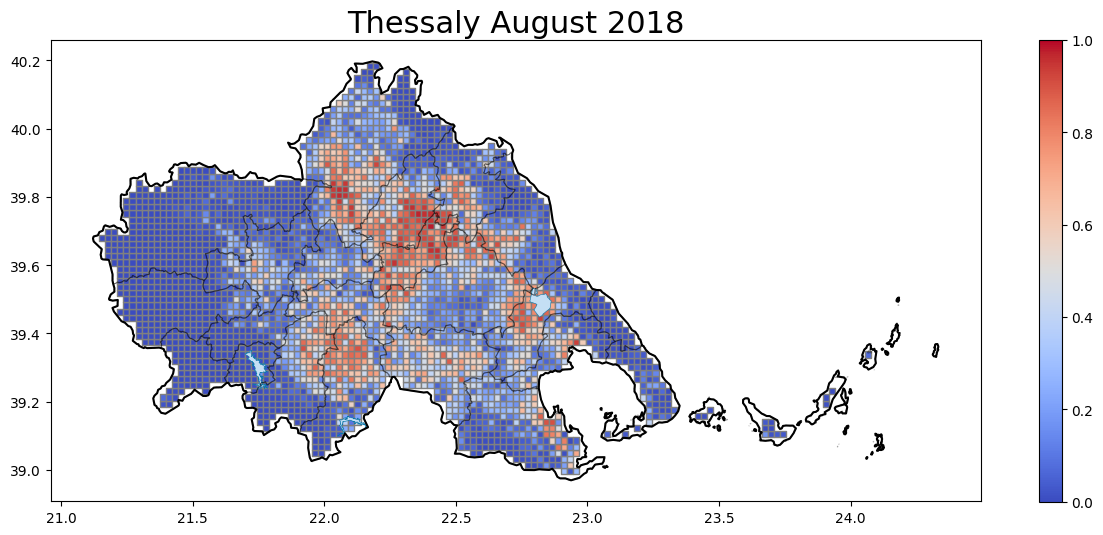

In [95]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)

plt.title(f'{NUTS2} {month_dict.get(results_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

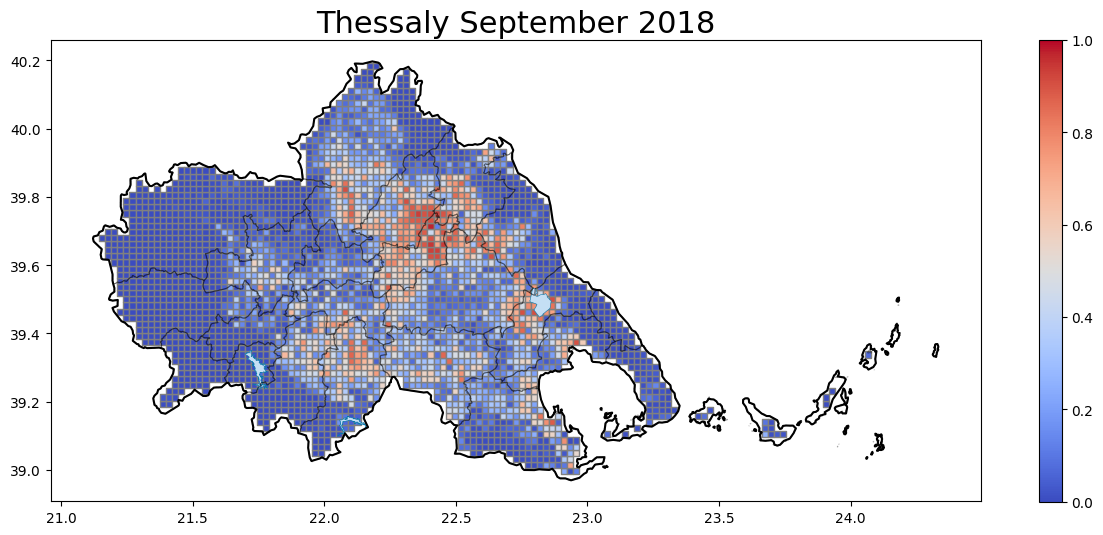

In [96]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)

plt.title(f'{NUTS2} {month_dict.get(results_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

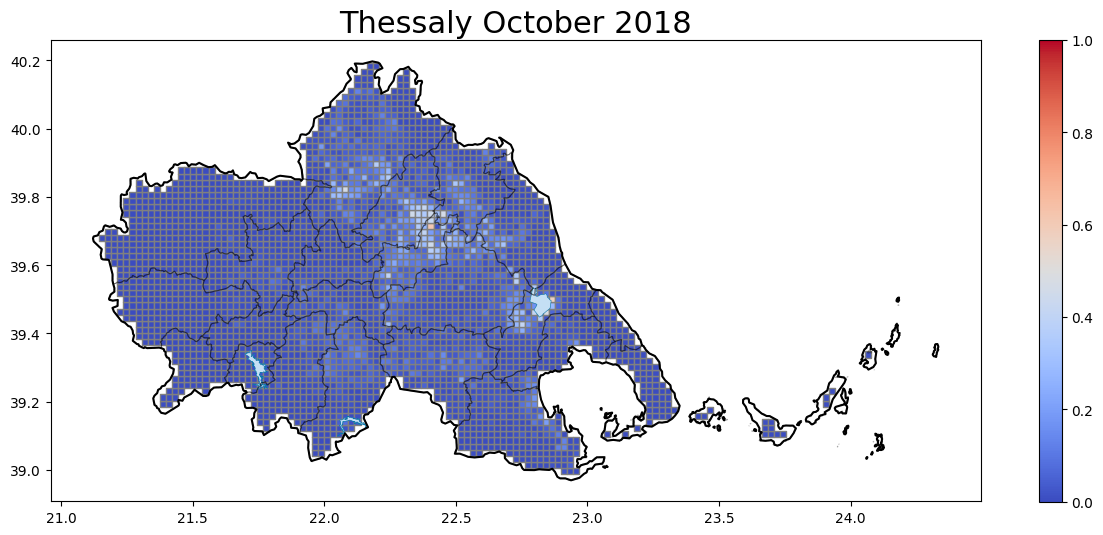

In [97]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)

plt.title(f'{NUTS2} {month_dict.get(results_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [98]:
fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_lau1, 
                                 index_col='cell_number', color_col='risk_score', hover_name='lau1', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=700)

fig.show()
# fig.write_html(f"2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")